In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FormatStrFormatter

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['axes.unicode_minus'] = True
plt.rcParams['font.family'] = 'Arial'

In [3]:
ammoniaResultsFileName = 'Ammonia economics.xlsx'
methanolResultsFileName = 'Methanol economics.xlsx'

In [4]:
ammoniaDF = pd.read_excel(os.path.join('..', 'Results', ammoniaResultsFileName), sheet_name = 'Overall', index_col = 0)
methanolDF = pd.read_excel(os.path.join('..', 'Results', methanolResultsFileName), sheet_name = 'Overall', index_col = 0)

In [5]:
def breakdown_plots(chemical, originalDF, ax):
    xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

    df_plot_new = pd.DataFrame()
    df_plot = originalDF.T
    if chemical == 'ammonia':
        columns_to_drop = [col for col in df_plot.columns if 'Low' in col or 'High' in col]
        df_plot = df_plot.drop(columns = columns_to_drop)
        naturalGasFeedCols = df_plot.columns[df_plot.columns.str.contains('natural gas, feedstock')]
        naturalGasHeatCols = df_plot.columns[df_plot.columns.str.contains('natural gas, heating')]
        gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('electricity, from grid')]
        greenCols = df_plot.columns[df_plot.columns.str.contains('hydrogen')]
        nitrogenCols = df_plot.columns[df_plot.columns.str.contains('nitrogen')]
        capexCols = df_plot.columns[df_plot.columns.str.contains('CAPEX contribution')]
        fixedCostsCols = df_plot.columns[df_plot.columns.str.contains('Fixed costs contribution')]
        otherCols = list(set(df_plot.columns) - set(naturalGasFeedCols) - set(naturalGasHeatCols) - set(gridElectricityCols) - set(greenCols) - set(nitrogenCols) - set(capexCols) - set(fixedCostsCols))
    elif chemical == 'methanol':
        columns_to_drop = [col for col in df_plot.columns if 'Low' in col or 'High' in col]       
        df_plot = df_plot.drop(columns = columns_to_drop)
        naturalGasFeedCols = df_plot.columns[df_plot.columns.str.contains('natural gas, feedstock')]
        naturalGasHeatCols = df_plot.columns[df_plot.columns.str.contains('natural gas, heating')]
        gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('electricity, from grid')]
        greenCols = df_plot.columns[df_plot.columns.str.contains('hydrogen')]
        nitrogenCols = df_plot.columns[df_plot.columns.str.contains('carbon dioxide')]
        capexCols = df_plot.columns[df_plot.columns.str.contains('CAPEX contribution')]
        fixedCostsCols = df_plot.columns[df_plot.columns.str.contains('Fixed costs contribution')]
        otherCols = list(set(df_plot.columns) - set(naturalGasFeedCols) - set(naturalGasHeatCols) - set(gridElectricityCols) - set(greenCols) - set(nitrogenCols) - set(capexCols) - set(fixedCostsCols))

    df_plot_new['Natural gas feed'] = df_plot[naturalGasFeedCols].sum(axis = 1)  
    df_plot_new['Other utilities'] = df_plot[otherCols].sum(axis = 1)  
    df_plot_new['Hydrogen'] = df_plot[greenCols].sum(axis = 1) 
    df_plot_new['Nitrogen'] = df_plot[nitrogenCols].sum(axis = 1) 
    df_plot_new['Grid electricity'] = df_plot[gridElectricityCols].sum(axis = 1)  
    df_plot_new['Natural gas utilities'] = df_plot[naturalGasHeatCols].sum(axis = 1)  
    df_plot_new['Fixed costs'] = df_plot[fixedCostsCols].sum(axis = 1)  
    df_plot_new['CAPEX'] = df_plot[capexCols].sum(axis = 1)  

    # Rearrange the DataFrame to match the desired order
    new_order = []
    num_groups = len(df_plot_new['Natural gas feed']) // 3
    for i in range(num_groups):
        new_order.extend([i + num_groups * j for j in range(3)])

    df_rearranged = df_plot_new.iloc[new_order]
    
    colors = ['#808080', '#167f99', '#a9d898', '#6dd2ea', '#fb7b71', '#b71205', '#52318e', '#a78dd8']
    df_plot_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)
    # ax.scatter(xPts, df_plot_new.sum(axis = 1), facecolor = 'yellow', edgecolors = '#808080', s = 15, linewidths = 0.4, zorder = 5)
    sum = df_plot_new.sum(axis = 1).reset_index(drop = True)

    # for i in range(0, len(xPts)):
    #     average = sum[i]
    #     errorsLowTemp = sensitivityDF['Low'][i]
    #     errorsHighTemp = sensitivityDF['High'][i]
    #     if sum[i] > 0:
    #         ax.plot([xPts[i]]*2, [average, errorsHighTemp], color = '#000000', linewidth = 0.5)
    #         ax.plot([xPts[i]]*2, [errorsLowTemp, average], color = '#ffffff', linewidth = 0.5)
    #         ax.errorbar(xPts[i], errorsHighTemp, yerr = 0, capsize = 2, elinewidth = 0.5, color = "#000000")
    #         ax.errorbar(xPts[i], errorsLowTemp, yerr = 0, capsize = 2, elinewidth = 0.5, color = "#ffffff")


    ax.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
    # ax.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    # ax.axvline(x = 7.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    # ax.axvline(x = 11.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.legend([], frameon = False)

In [6]:
df = ammoniaDF.T.drop(columns = ['Low', 'High'])
ammmoniaTotals = df.sum(axis = 1)
ammoniaErrorsHigh = ammoniaDF.T['High'] - ammmoniaTotals
ammoniaErrorsLow = ammmoniaTotals - ammoniaDF.T['Low']

df = methanolDF.T.drop(columns = ['Low', 'High'])
methanolTotals = df.sum(axis = 1)
methanolErrorsHigh = methanolDF.T['High'] - methanolTotals
methanolErrorsLow = methanolTotals - methanolDF.T['Low']

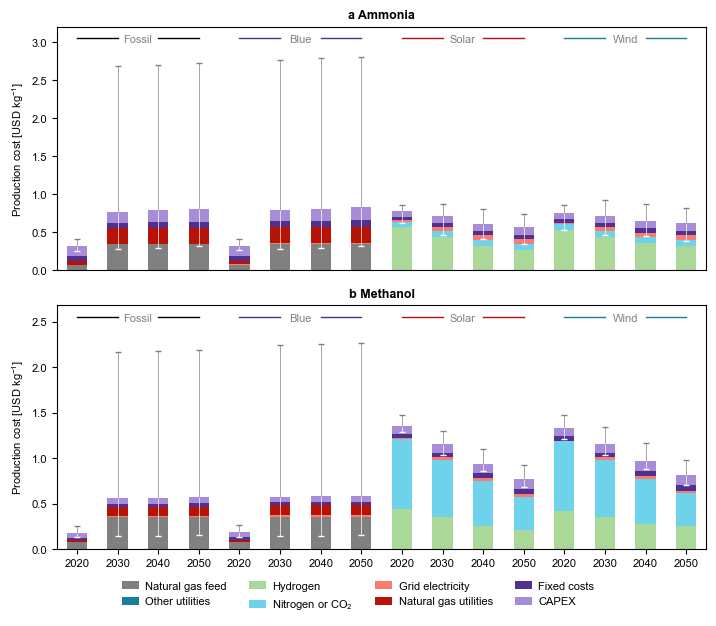

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (fig_length[2], fig_height*0.6))

xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

x_values = [0, 2, 4, 6, 8, 10, 12, 14]
colors = ['#000000', '#000000', '#52318E', '#52318E', '#B71205', '#B71205', '#167F99', '#167F99']

breakdown_plots('ammonia', ammoniaDF, ax1)
ax1.xaxis.set_ticks_position('none')
ax1.set_ylabel('Production cost [USD kg$^\mathdefault{-1}$]')
ax1.set_title('a Ammonia', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax1.set_xticks([])
ax1.text(1.5, 3, 'Fossil', ha = 'center', color = '#808080')
ax1.text(5.5, 3, 'Blue', ha = 'center', color = '#808080')
ax1.text(9.5, 3, 'Solar', ha = 'center', color = '#808080') 
ax1.text(13.5, 3, 'Wind', ha = 'center', color = '#808080') 

plotline, caplines, barlinecols = ax1.errorbar(
                    xPts, ammmoniaTotals, yerr = ammoniaErrorsHigh, lolims = True, ls = "none",
                    capsize = 0, elinewidth = 0.5, color='#808080')
caplines[0].set_marker('_')
caplines[0].set_markersize(4)
plotline, caplines, barlinecols = ax1.errorbar(
                    xPts, ammmoniaTotals, yerr = ammoniaErrorsLow, uplims = True, ls = "none",
                    capsize = 0, elinewidth = 0.5, color='#ffffff')
caplines[0].set_marker('_')
caplines[0].set_markersize(4)

y_value = 3.05
for i in range(0, len(x_values)):
    ax1.plot([x_values[i], x_values[i] + 1], [y_value, y_value], linestyle = '-', linewidth = 1, color = colors[i])

breakdown_plots('methanol', methanolDF, ax2)
ax2.set_ylabel('Production cost [USD kg$^\mathdefault{-1}$]')
ax2.set_title('b Methanol', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax2.set_xticks(xPts)  
ax2.set_xticklabels(['2020', '2030', '2040', '2050']*4, rotation = 0, ha = 'center')  
ax2.text(1.5, 2.5, 'Fossil', ha = 'center', color = '#808080')
ax2.text(5.5, 2.5, 'Blue', ha = 'center', color = '#808080')
ax2.text(9.5, 2.5, 'Solar', ha = 'center', color = '#808080')
ax2.text(13.5, 2.5, 'Wind', ha = 'center', color = '#808080') 

plotline, caplines, barlinecols = ax2.errorbar(
                    xPts, methanolTotals, yerr = methanolErrorsHigh, lolims = True, ls = "none",
                    capsize = 0, elinewidth = 0.5, color='#808080')
caplines[0].set_marker('_')
caplines[0].set_markersize(4)
plotline, caplines, barlinecols = ax2.errorbar(
                    xPts, methanolTotals, yerr = methanolErrorsLow, uplims = True, ls = "none",
                    capsize = 0, elinewidth = 0.5, color='#ffffff')
caplines[0].set_marker('_')
caplines[0].set_markersize(4)

y_value = 2.55
for i in range(0, len(x_values)):
    ax2.plot([x_values[i], x_values[i] + 1], [y_value, y_value], linestyle = '-', linewidth = 1, color = colors[i])

handles, labels = ax2.get_legend_handles_labels()
labels[3] = 'Nitrogen or CO$_\mathdefault{2}$'
legend = fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.07), frameon = False, ncol = 4, handletextpad = 0.1)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

filepath = os.path.join('..', 'Plots', 'Economics breakdown')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)